---- HAM10000 Summary ----
Total Images: 10015

Class Counts:
cell_type
Nevus                   6705
Melanoma                1113
Benign Keratosis        1099
Basal Cell Carcinoma     514
Actinic Keratoses        327
Vascular Lesions         142
Dermatofibroma           115
Name: count, dtype: int64

Top 5 Localization Sites:
localization
back               2192
lower extremity    2077
trunk              1404
upper extremity    1118
abdomen            1022
Name: count, dtype: int64
------------------------



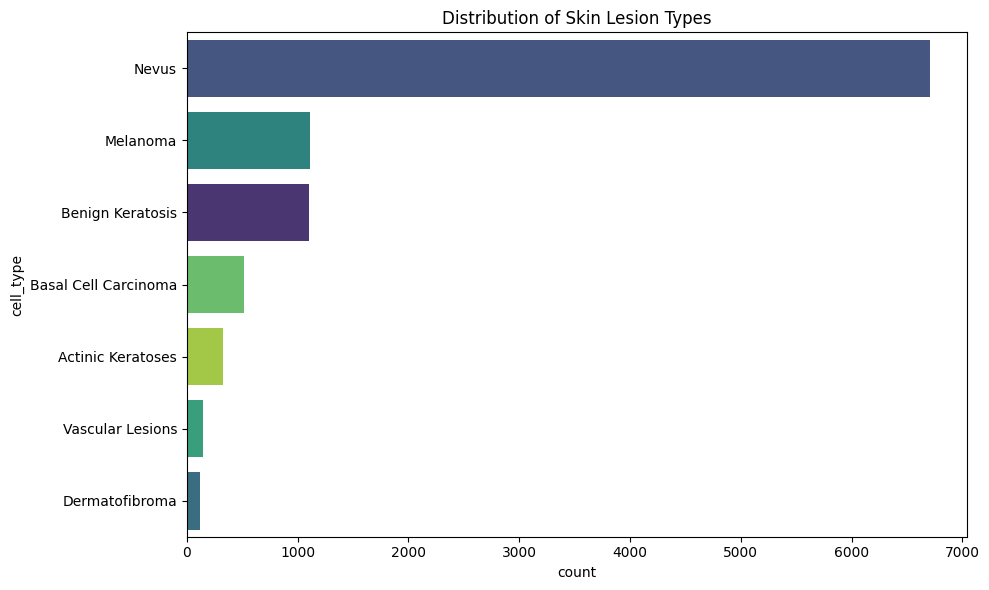

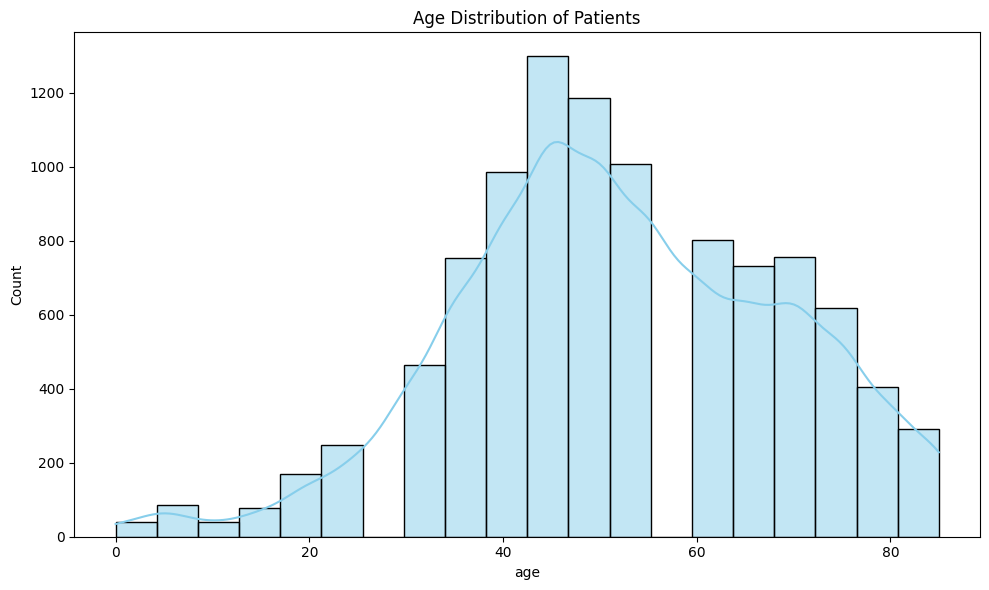

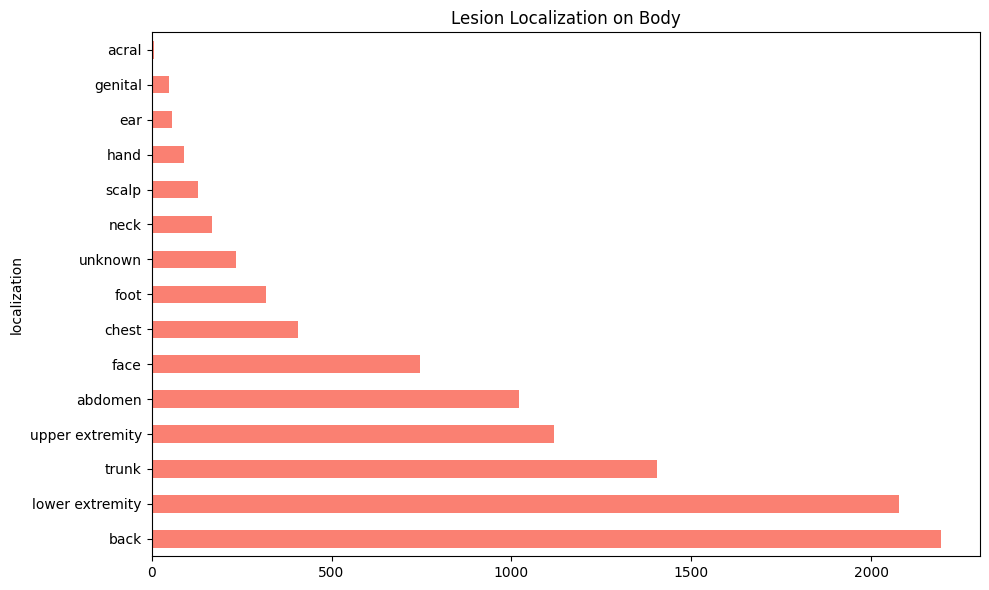

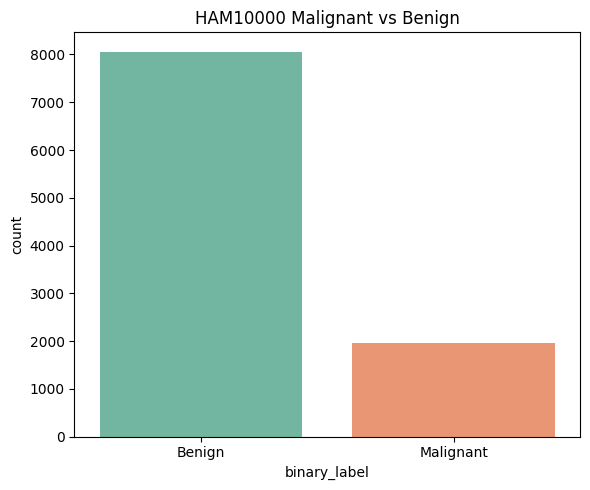



---- ISIC 2019 Summary ----
Total Images: 25331

Class Counts:
cell_type
Melanocytic Nevus          12875
Melanoma                    4522
Basal Cell Carcinoma        3323
Benign Keratosis            2624
Actinic Keratosis            867
Squamous Cell Carcinoma      628
Vascular Lesion              253
Dermatofibroma               239
Name: count, dtype: int64
------------------------



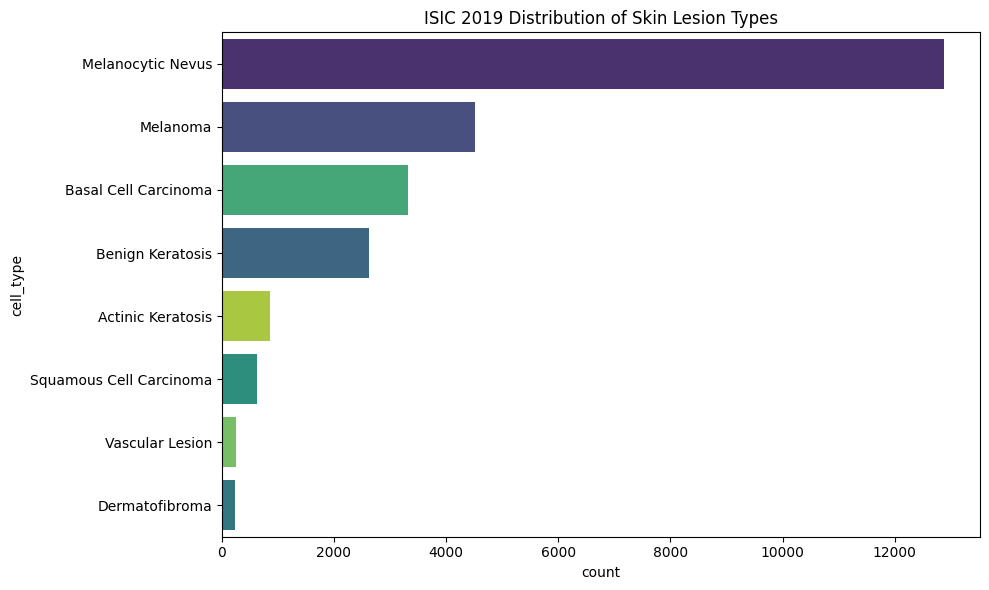

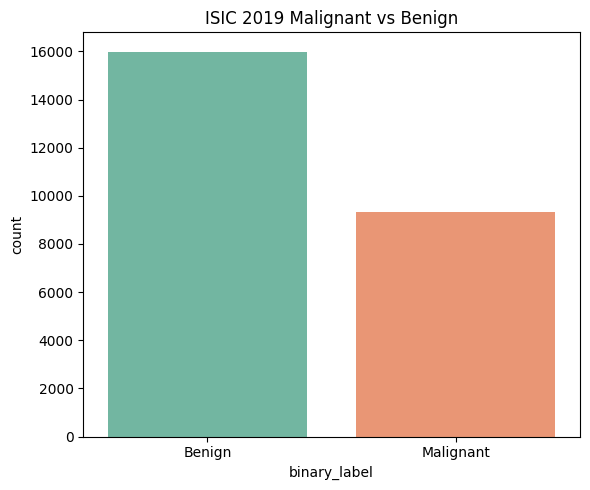

In [ ]:
#exploratory data analysis VERSION 2 WITH HAM10000 & ISIC
#distribution and information about HAM10000 & ISIC
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('project-root/experiments/results/eda', exist_ok=True)

#HAM10000
metadata = 'project-root/data/src_data/ham10000/HAM10000_metadata.csv'
df = pd.read_csv(metadata)

labels = {
    'nv': 'Nevus',
    'mel': 'Melanoma',
    'bkl': 'Benign Keratosis',
    'bcc': 'Basal Cell Carcinoma',
    'akiec': 'Actinic Keratoses',
    'vasc': 'Vascular Lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(labels)

#summary
print("---- HAM10000 Summary ----")
print(f"Total Images: {len(df)}")
print("\nClass Counts:")
print(df['cell_type'].value_counts())
print("\nTop 5 Localization Sites:")
print(df['localization'].value_counts().head(5))
print("------------------------\n")

# class distribution
plt.figure(figsize=(10,6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, hue='cell_type', palette='viridis', legend=False)
plt.title('Distribution of Skin Lesion Types')
#so image doesnt clip/overlap with other elements and borders
plt.tight_layout()
plt.savefig('project-root/experiments/results/eda/class_distribution.png')
plt.show()

# age distribution
plt.figure(figsize=(10,6))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Patients')
plt.tight_layout()
plt.savefig('project-root/experiments/results/eda/age_distribution.png')
plt.show()

# skin lesion localization distribution
plt.figure(figsize=(10,6))
df['localization'].value_counts().plot(kind='barh', color='salmon')
plt.title('Lesion Localization on Body')
plt.tight_layout()
plt.savefig('project-root/experiments/results/eda/localization.png')
plt.show()

#malignant vs benign breakdown
malignant = ['Melanoma', 'Basal Cell Carcinoma', 'Actinic Keratoses']
df['binary_label'] = df['cell_type'].apply(lambda x: 'Malignant' if x in malignant else 'Benign')

plt.figure(figsize=(6,5))
sns.countplot(x='binary_label', data=df, hue='binary_label', palette='Set2', legend=False)
plt.title('HAM10000 Malignant vs Benign')
plt.tight_layout()
plt.savefig('project-root/experiments/results/eda/ham_malignant_vs_benign.png')
plt.show()

#ISIC 2019, doesnt have much metadata about patients. just lesions.
isic_metadata = 'project-root/data/src_data/isic2019/ISIC_2019_Training_GroundTruth.csv'
isic_df = pd.read_csv(isic_metadata)

isic_labels = {
    'MEL': 'Melanoma',
    'NV': 'Melanocytic Nevus',
    'BCC': 'Basal Cell Carcinoma',
    'AK': 'Actinic Keratosis',
    'BKL': 'Benign Keratosis',
    'DF': 'Dermatofibroma',
    'VASC': 'Vascular Lesion',
    'SCC': 'Squamous Cell Carcinoma'
}

#convert one-hot encoding back to a single class column
isic_df['cell_type'] = isic_df[list(isic_labels.keys())].idxmax(axis=1).map(isic_labels)

#summary
print("\n\n---- ISIC 2019 Summary ----")
print(f"Total Images: {len(isic_df)}")
print("\nClass Counts:")
print(isic_df['cell_type'].value_counts())
print("------------------------\n")

# class distribution
plt.figure(figsize=(10,6))
sns.countplot(y='cell_type', data=isic_df, order=isic_df['cell_type'].value_counts().index, hue='cell_type', palette='viridis', legend=False)
plt.title('ISIC 2019 Distribution of Skin Lesion Types')
plt.tight_layout()
plt.savefig('project-root/experiments/results/eda/isic_class_distribution.png')
plt.show()

#malignant vs benign breakdown
isic_malignant = ['MEL', 'BCC', 'AK', 'SCC']
isic_df['binary_label'] = isic_df[isic_malignant].max(axis=1).map({1: 'Malignant', 0: 'Benign'})

plt.figure(figsize=(6,5))
sns.countplot(x='binary_label', data=isic_df, hue='binary_label', palette='Set2', legend=False)
plt.title('ISIC 2019 Malignant vs Benign')
plt.tight_layout()
plt.savefig('project-root/experiments/results/eda/isic_malignant_vs_benign.png')
plt.show()